# R01 — Win/Loss Rates per Opponent

**Goal:** Understand how our Autopilot robot performs against each opponent.
We look at win rate, net damage, and hit rates to identify weak matchups.

- **Win rate**: Fraction of rounds we won (0.5 = evenly matched)
- **Net damage**: Damage dealt − received per round (positive = winning)
- **Hit rates**: Our accuracy vs how often they hit us

In [1]:
import sys; sys.path.insert(0, '..')
from retrospective._retro_helpers import load_local_scores, add_opponent_names
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

scores = load_local_scores()
scores = add_opponent_names(scores)
print(f'Loaded {len(scores):,} score rows from Autopilot perspective')
print(f'Opponents: {sorted(scores["opponent_name"].unique())}')

Indexed 96 ticks.csv files across 6 distinct robots from 1 root(s).
Selected 6 robots × ~100 battles = 96 (battle, robot) pairs to load.


D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Loaded 96 scores.csv files → 3,360 rows × 17 cols, 6 robots (~0.6 MB)
Loaded 1,680 score rows from Autopilot perspective
Opponents: ['DengerousRoBatra 1.3', 'Glacier 0.3.2', 'Midboss 1q.fast', 'ScalarR 0.005h.053-noshield', 'Shadow 3.83c', 'Unknown']


In [2]:
# Per-opponent summary
opp_stats = scores.groupby('opponent_name').agg(
    rounds=('round', 'count'),
    avg_win_rate=('win_rate', 'mean'),
    avg_dmg_dealt=('damage_dealt', 'mean'),
    avg_dmg_received=('damage_received', 'mean'),
    avg_our_hr=('our_hit_rate', 'mean'),
    avg_opp_hr=('opponent_hit_rate', 'mean'),
).reset_index()
opp_stats['avg_net_damage'] = opp_stats['avg_dmg_dealt'] - opp_stats['avg_dmg_received']
opp_stats = opp_stats.sort_values('avg_net_damage', ascending=True)
print(opp_stats.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

              opponent_name  rounds  avg_win_rate  avg_dmg_dealt  avg_dmg_received  avg_our_hr  avg_opp_hr  avg_net_damage
                    Unknown      35         0.000          2.286            88.923       0.025       0.488         -86.637
ScalarR 0.005h.053-noshield     315         0.000          2.469            87.437       0.029       0.464         -84.967
               Shadow 3.83c     315         0.000          1.884            85.301       0.022       0.421         -83.416
              Glacier 0.3.2     350         0.000          3.339            82.408       0.031       0.398         -79.069
       DengerousRoBatra 1.3     315         0.000          6.799            84.702       0.062       0.390         -77.902
            Midboss 1q.fast     350         0.000          2.466            79.474       0.023       0.440         -77.008


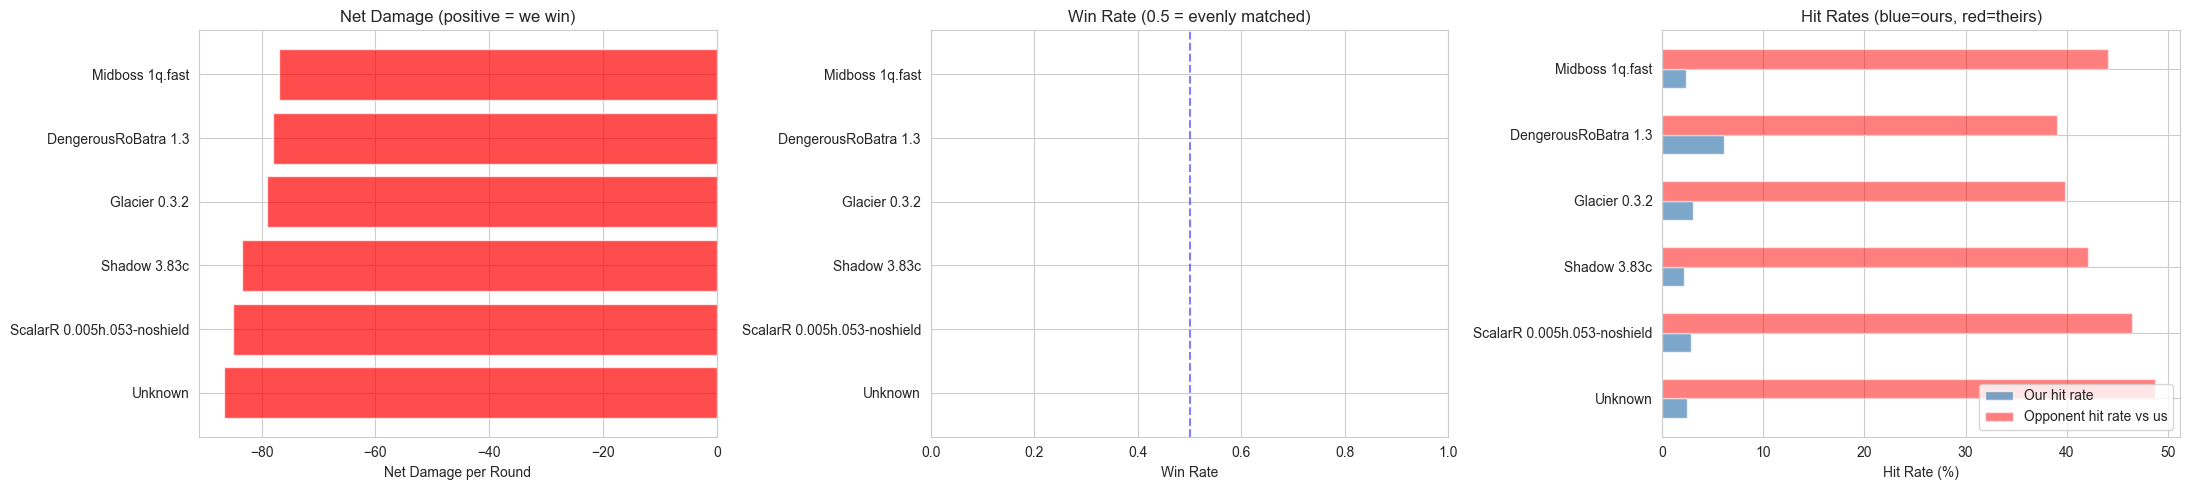

In [3]:
# Charts
fig, axes = plt.subplots(1, 3, figsize=(22, max(5, len(opp_stats)*0.6)))

# Net damage
ax = axes[0]
colors = ['green' if x > 0 else 'red' for x in opp_stats['avg_net_damage']]
ax.barh(opp_stats['opponent_name'], opp_stats['avg_net_damage'], color=colors, alpha=0.7)
ax.set_xlabel('Net Damage per Round')
ax.set_title('Net Damage (positive = we win)')
ax.axvline(x=0, color='black', linewidth=0.5)

# Win rate
ax = axes[1]
colors = ['green' if x > 0.5 else 'orange' if x > 0.3 else 'red' for x in opp_stats['avg_win_rate']]
ax.barh(opp_stats['opponent_name'], opp_stats['avg_win_rate'], color=colors, alpha=0.7)
ax.set_xlabel('Win Rate')
ax.set_title('Win Rate (0.5 = evenly matched)')
ax.axvline(x=0.5, color='blue', linestyle='--', alpha=0.5)
ax.set_xlim(0, 1)

# Hit rates
ax = axes[2]
x = range(len(opp_stats))
ax.barh([i - 0.15 for i in x], opp_stats['avg_our_hr']*100, height=0.3, color='steelblue', alpha=0.7, label='Our hit rate')
ax.barh([i + 0.15 for i in x], opp_stats['avg_opp_hr']*100, height=0.3, color='red', alpha=0.5, label='Opponent hit rate vs us')
ax.set_yticks(list(x))
ax.set_yticklabels(opp_stats['opponent_name'])
ax.set_xlabel('Hit Rate (%)')
ax.set_title('Hit Rates (blue=ours, red=theirs)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [4]:
# Overall summary
print(f'=== Overall Performance ===')
print(f'Total opponents: {len(opp_stats)}')
print(f'Total rounds: {len(scores)}')
print(f'Overall win rate: {scores["win_rate"].mean():.3f}')
print(f'Overall our hit rate: {scores["our_hit_rate"].mean()*100:.1f}%')
print(f'Overall opponent hit rate: {scores["opponent_hit_rate"].mean()*100:.1f}%')
print(f'Overall avg net damage/round: {scores["net_damage"].mean():.1f}')
print(f'Positive net damage (winning): {(opp_stats["avg_net_damage"] > 0).sum()} opponents')
print(f'Negative net damage (losing):  {(opp_stats["avg_net_damage"] < 0).sum()} opponents')

=== Overall Performance ===
Total opponents: 6
Total rounds: 1680
Overall win rate: 0.000
Overall our hit rate: 3.3%
Overall opponent hit rate: 42.4%
Overall avg net damage/round: -80.5
Positive net damage (winning): 0 opponents
Negative net damage (losing):  6 opponents
